In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as maths
import scipy
from scipy import stats
import astropy.stats as astro

In [3]:
antTrackDF = pd.read_csv("AbbottsWoodsCombinedTidy.csv")

antTrackDF['ID'] = antTrackDF.ID.astype(str)

/tmp/ipykernel_8976/2758679799.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  antTrackDF = pd.read_csv("AbbottsWoodsCombinedTidy.csv")


In [4]:
save_folder = "abbotsplots/multipath/"

In [5]:
def speed_accumDist(usedf, framePerSec, total_time_s, total_frames): # 3 
            delta_distPerFrame_cm = distPerFrame(usedf)
            # accumulated distance using delta dist (per frame)
            usedf['accumdist'] = usedf.loc[:,'delta_distance(pix)'].cumsum() # add the delta distances. last calc = total distance
            # total distance travelled looking at the final entry for detla dist cumsum
            total_dist_travelled = usedf['accumdist'].iloc[-1]
            # turning this total distance in to cm
            total_dist_cm = total_dist_travelled/10 # cm
            # turning this distance into speed by dividing by time (frames/second * total number of frames)
            total_dist_cm_speed_frames = (total_dist_cm/total_frames) * framesPerSec 
            #total_dist_cm_speed_frames_d = total_dist_cm / framesPerSec 
            total_dist_cm_speed_time = total_dist_cm / total_time_s 
            return total_dist_cm_speed_frames, total_dist_cm_speed_time, total_dist_cm, usedf

In [6]:
def speedDistStats(df, xname="x", yname="x", framesPerSec=100):
    """creates lists for speed, distance travelled, and straightness of path per frame
    adds columns to df copy """
    usedf = df.copy()
    dist_list = []
    speed_list = []
    straight_list = []
    
    _x = np.array(usedf[xname])
    _y =  np.array(usedf[yname])
    
    num_frames = usedf['frame'].iloc[-1] - usedf['frame'].iloc[0]
    total_time_s = num_frames/framesPerSec
    
    theta, r = cart2pola(_x, _y)
    degrees = theta*180/np.pi  # convert to degrees
    
    usedf['delta_distance(pix)'] = np.sqrt(usedf.loc[:,xname].diff()**2 + usedf.loc[:,yname].diff()**2) # distance diff per frame
    usedf['speed(px/s)'] = usedf.loc[:,'delta_distance(pix)'] / framesPerSec # speed = dist / time
    usedf['accumdist'] = usedf.loc[:,'delta_distance(pix)'].cumsum() # add the delta distances. last calc = total distance
    total_dist_travelled = usedf['accumdist'].iloc[-1]
                       
    Average_speed = total_dist_travelled / (total_frames * framesPerSec) # take total distance and divide by total time taken #
    
    dist_list.append(total_dist_travelled)
    speed_list.append(Average_speed)

    beeline =((_x[-1] - _x[1])**2 + (_y[-1] - _y[1])**2)**0.5
    straightness = beeline / total_dist_travelled
    straight_list.append(straightness)
    return dist_list, speed_list, straight_list, usedf

In [7]:
def stats_condition(df, nest, condition, all=True):
    # This function will loop though all IDs of a nest and or condition
    # it then calculates path speed, straightness, distance travelled (between rows i & i-1 and total), 
    # these metrics are then plotted in box plots
    
    newdf = df[(df['Nest']==nest) & (df['Condition']== condition)] # s
    
    unique_ids = np.unique(newdf['ID']) # get the unique IDs in a list
    outdf = pd.DataFrame({'A' : [np.nan]})
    outdf.dropna().empty
    #outdf.dropna().empty
    #print("unique IDs in nest/ condition combo:", type(unique_ids), unique_ids) 

    # create lists to store one time metrics for later plotting
    straight_list = []
    speed_list = []
    dist_list = []
    framesPerSec = 1/100#25  # video recorded in 25 frames/ second

    for id in unique_ids:    
        # subset by ID - individual trial
        usedf = newdf[newdf['ID'] == id].copy()
        if len(usedf) <=0:
            continue
        #print(f"ID {id} len {len(usedf)}")
        #print('usedf', usedf)
        #print(len(usedf['frame']))
        #print(usedf['frame'].iloc[0])
        #print('last frame : ',usedf['frame'].iloc[-1])
        max_len=len(usedf)
        total_frames = usedf['frame'].iloc[-1]
        
        _x = np.array(usedf['x'])
        _y =  np.array(usedf['y'])
        theta = np.arctan2(_y, _x) # radians. converting to polar coordinates
        degrees = theta*180/np.pi  # degrees
        
        usedf['delta_distance(pix)'] = np.sqrt(usedf.loc[:,'x'].diff()**2 + usedf.loc[:,'y'].diff()**2) # distance diff per frame
        # following matlab equation to calc rho in cart2pol "rho is the distance from the origin to a point in the x-y plane." https://uk.mathworks.com/help/matlab/ref/cart2pol.html

        usedf['speed(px/s)'] = usedf.loc[:,'delta_distance(pix)'] / framesPerSec # speed = dist / time

        usedf['accumdist'] = usedf.loc[:,'delta_distance(pix)'].cumsum() # add the delta distances. last calc = total distance
        total_dist_travelled = usedf['accumdist'].iloc[-1]

        #print("last frame val", usedf['frame'].iloc[-1] , "length of df", max_len) # len(df) is sometimes less than ['frame'][-1]
        #                                           
        Average_speed = total_dist_travelled / (total_frames * framesPerSec) # take total distance and divide by total time taken #
        usedf['ave_speed'] = Average_speed
        #dist_list.append(total_dist_travelled)
        usedf['total_dist'] = total_dist_travelled
        #speed_list.append(Average_speed)
        usedf['ave_speed'] = Average_speed

        beeline =((_x[-1] - _x[1])**2 + (_y[-1] - _y[1])**2)**0.5
        straightness = beeline / total_dist_travelled
        #straight_list.append(straightness)
        usedf['straightness'] = straightness
        #print("usedf before if all: ",usedf)

        #newdf = newdf.merge(usedf, on=['Date', 'ID','frame', 'x', 'y', 'Nest', 'Condition'])
        #print("newdf before if all: ", newdf.head())
        if all:
            #print("last heading",usedf['y'].iloc[-1])
            ##print("angle in radians:  ", theta[-1])
            #print("angle in degrees:  ", degrees[-1])
            #print("straightness:  ", straightness)
            
            newdf = newdf.replace(np.nan,0)
        outdf = pd.concat([outdf, usedf])
        #print("newdf after if all: ", newdf.head())
    #print("newdf before end: ", newdf.head())
    print("in func out keys : ",outdf.keys())
    return outdf

        
        

In [8]:
antTrackDF.keys()
from manipulateDFfns import addCols2DF

In [9]:
alldist_list = []
allspeed_list = []
allstraight_list = []

usedf = antTrackDF.copy()

unique_conditions = np.unique(usedf['Condition'])
unique_nests = np.unique(usedf['Nest'])
outdf = pd.DataFrame({'A' : [np.nan]})
outdf.dropna().empty
for nest in unique_nests:
    ndist_list = []
    nspeed_list = []
    
    nstraight_list = []
    print('----    ------')
    print(nest)
    for condition in unique_conditions:
        print(condition)
        #print('in house last frame:',usedf['frame'].iloc[-1])
        df = stats_condition(usedf, nest=nest, condition=condition)
        df = df.iloc[1:]
        print(df.head(2))
        outdf = pd.concat([outdf, df])
        print("out2",outdf.head(2))
        outdf = outdf.drop('A', axis=1)
        #usedf = pd.merge(usedf, df, how='outer', on=['Date', 'ID','frame', 'x', 'y', 'Nest', 'Condition'])
        #print(dist_list)
print(outdf)

----    ------
NewNest
Eye-capped off-route 1
in func out keys :  Index(['A', 'Date', 'ID', 'frame', 'x', 'y', 'Nest', 'Condition',
       'delta_distance(pix)', 'speed(px/s)', 'accumdist', 'ave_speed',
       'total_dist', 'straightness'],
      dtype='object')
          A    Date   ID  frame         x         y     Nest  \
2328158 NaN  Sep-23  192    0.0 -7.874331 -5.678055  NewNest   
2328159 NaN  Sep-23  192    1.0 -7.179074 -5.738707  NewNest   

                      Condition  delta_distance(pix)  speed(px/s)  accumdist  \
2328158  Eye-capped off-route 1                  NaN          NaN        NaN   
2328159  Eye-capped off-route 1             0.697898    69.789787   0.697898   

         ave_speed  total_dist  straightness  
2328158  50.712274  344.336343      0.858155  
2328159  50.712274  344.336343      0.858155  
out2           A    Date   ID  frame         x         y     Nest  \
0       NaN     NaN  NaN    NaN       NaN       NaN      NaN   
2328158 NaN  Sep-23  192    0

In [10]:
outdf = outdf.iloc[1:]
print(outdf.head())
print()
print(outdf.tail())

           Date   ID  frame         x         y     Nest  \
2328158  Sep-23  192    0.0 -7.874331 -5.678055  NewNest   
2328159  Sep-23  192    1.0 -7.179074 -5.738707  NewNest   
2328160  Sep-23  192    2.0 -6.876221 -5.762784  NewNest   
2328161  Sep-23  192    3.0 -6.972239 -5.692476  NewNest   
2328162  Sep-23  192    4.0 -6.971978 -5.744445  NewNest   

                      Condition  delta_distance(pix)  speed(px/s)  accumdist  \
2328158  Eye-capped off-route 1                  NaN          NaN        NaN   
2328159  Eye-capped off-route 1             0.697898    69.789787   0.697898   
2328160  Eye-capped off-route 1             0.303809    30.380890   1.001707   
2328161  Eye-capped off-route 1             0.119007    11.900717   1.120714   
2328162  Eye-capped off-route 1             0.051969     5.196911   1.172683   

         ave_speed  total_dist  straightness  
2328158  50.712274  344.336343      0.858155  
2328159  50.712274  344.336343      0.858155  
2328160  50.71227

In [11]:
import seaborn as sns

In [12]:
outdf.keys()

Index(['Date', 'ID', 'frame', 'x', 'y', 'Nest', 'Condition',
       'delta_distance(pix)', 'speed(px/s)', 'accumdist', 'ave_speed',
       'total_dist', 'straightness'],
      dtype='object')

In [14]:
outdf['Nest']

2328158    NewNest
2328159    NewNest
2328160    NewNest
2328161    NewNest
2328162    NewNest
            ...   
429664      Wigwam
429665      Wigwam
429666      Wigwam
429667      Wigwam
429668      Wigwam
Name: Nest, Length: 2681836, dtype: object

In [16]:
print(np.unique(outdf['Condition']))
print("")
print(np.unique(outdf[outdf['Nest']=='NewNest']['Condition']))
print("")
print(np.unique(outdf[outdf['Nest']=='Wigwam']['Condition']))

['Eye-capped off-route 1' 'Eye-capped on-route 1' 'Minus 3m ZV'
 'Off-route 1 ZV' 'On-route 1 ZV' 'On-route 1B ZV' 'On-route 2 ZV'
 'Plus 3m ZV' 'Route 0m ZV' 'Unfamiliar FV' 'Unfamiliar ZV'
 'Unfamiliar ZV 2' 'Unfamiliar ZV 3']

['Eye-capped off-route 1' 'Eye-capped on-route 1' 'Minus 3m ZV'
 'Off-route 1 ZV' 'On-route 1 ZV' 'On-route 1B ZV' 'On-route 2 ZV'
 'Plus 3m ZV' 'Route 0m ZV' 'Unfamiliar FV' 'Unfamiliar ZV'
 'Unfamiliar ZV 2' 'Unfamiliar ZV 3']

['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']


In [11]:
c = [a for a in outdf.keys()]


In [12]:
np.unique(outdf['Nest'])

array(['NewNest', 'Wigwam'], dtype=object)

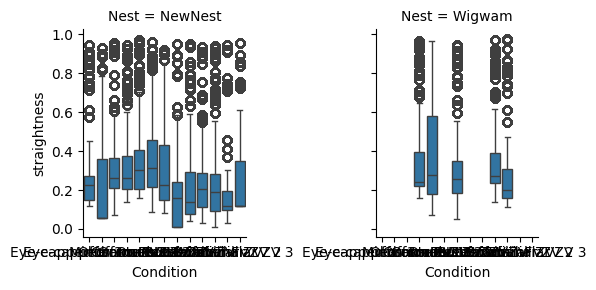

In [13]:
g = sns.FacetGrid(outdf, col="Nest")
g.map_dataframe(sns.boxplot, x = "Condition",y="straightness")

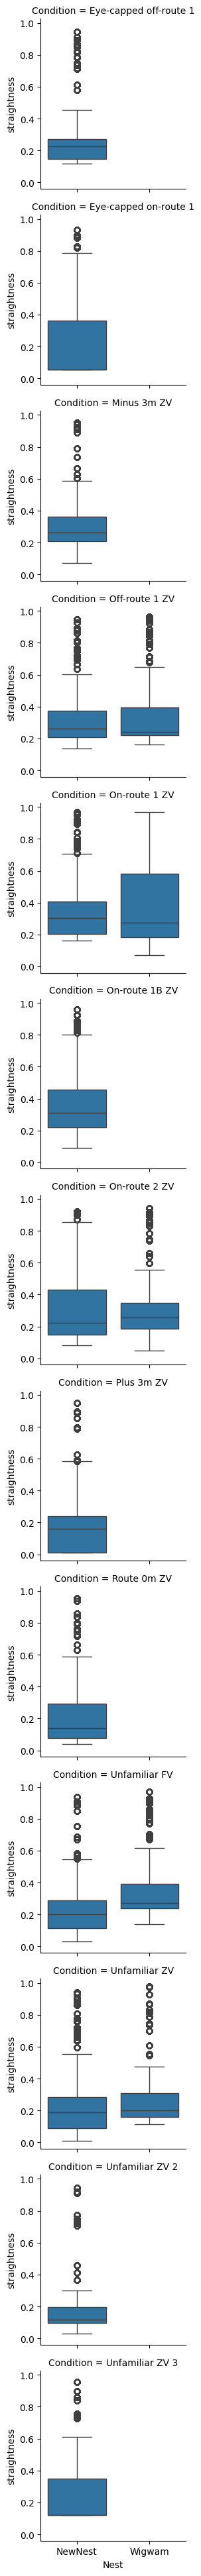

In [14]:
g = sns.FacetGrid(outdf, row="Condition")
g.map_dataframe(sns.boxplot, x = "Nest",y="straightness")

In [15]:
outdfWig = outdf[outdf['Nest']=='Wigwam']

print(np.unique(outdfWig['Condition']))

['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']


In [16]:
bothcond = np.unique(outdfWig['Condition'])
#for x in bothcond:
#  if x in :
#    newlist.append(x)
# mask = df['Subscription'].isin(active_statuses)
trimMask = outdf['Condition'].isin(bothcond)
print("TRi Mask : ",trimMask[:3])
outdfTrimmed = outdf[trimMask]
print("outtrimmed: ",outdfTrimmed.head(3))
#outdfTrimmed = outdf[outdf['Condition']  in bothcond]

print(np.unique(outdfTrimmed['Condition']))

TRi Mask :  2328158    False
2328159    False
2328160    False
Name: Condition, dtype: bool
outtrimmed:            Date   ID  frame         x         y     Nest       Condition  \
519306  Aug-21  561    0.0  9.136518 -2.818835  NewNest  Off-route 1 ZV   
519307  Aug-21  561    1.0  9.182885 -2.805765  NewNest  Off-route 1 ZV   
519308  Aug-21  561    2.0  9.191697 -2.636927  NewNest  Off-route 1 ZV   

        delta_distance(pix)  speed(px/s)  accumdist  ave_speed  total_dist  \
519306                  NaN          NaN        NaN  26.702984  619.776262   
519307             0.048174     4.817382   0.048174  26.702984  619.776262   
519308             0.169068    16.906788   0.217242  26.702984  619.776262   

        straightness  
519306      0.451304  
519307      0.451304  
519308      0.451304  
['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']


In [17]:
"""
 two datasets A and B feature by feature. If the p-value is less 

 unfam and fam
"""
conditions = [np.unique(outdfTrimmed['Condition'])]
for idx in range(len(conditions)-1):
    df1 = outdfTrimmed[outdfTrimmed['']== conditions[idx]]
    df2 = outdfTrimmed[outdfTrimmed['']== conditions[idx+1]]
    t_stat, p_value = stats.ttest_ind(df1['Condition'], df2['straightness'])
    print("T statistic:", t_stat)
    print("P-value:", p_value)

In [19]:
# f_oneway(*samples, axis=0, nan_policy='propagate', keepdims=False)[sourc
#stat, pval = stats.f_oneway(outdfTrimmed[''])

In [20]:
outdfTrimmed.keys()

Index(['Date', 'ID', 'frame', 'x', 'y', 'Nest', 'Condition',
       'delta_distance(pix)', 'speed(px/s)', 'accumdist', 'ave_speed',
       'total_dist', 'straightness'],
      dtype='object')

In [21]:
import pandas as pd
import scipy.stats as stats
import numpy as np

# Assuming your dataframe is called 'df'
# df = pd.read_csv('your_data.csv')  # Load your data

def perform_anova_by_condition(df, dependent_var):
    """
    Perform one-way ANOVA for a dependent variable across conditions
    """
    # Group data by conditions
    groups = [group[dependent_var].dropna() for name, group in df.groupby('Condition')]
    
    # Remove empty groups
    groups = [group for group in groups if len(group) > 0]
    
    if len(groups) < 2:
        return None, None, "Need at least 2 groups for ANOVA"
    
    # Perform ANOVA
    f_stat, p_value = stats.f_oneway(*groups)
    
    return f_stat, p_value, None

# Test each dependent variable
dependent_variables = ['ave_speed', 'straightness', 'total_dist']

print("One-way ANOVA Results:")
print("=" * 50)

for var in dependent_variables:
    f_stat, p_value, error = perform_anova_by_condition(outdfTrimmed, var)
    
    if error:
        print(f"{var}: {error}")
    else:
        print(f"{var}:")
        print(f"  F-statistic: {f_stat:.8f}")
        print(f"  p-value: {p_value:}") # .8f
        print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}")
        print()

# Alternative approach: More detailed analysis
print("\nDetailed Analysis by Condition:")
print("=" * 50)

for var in dependent_variables:
    print(f"\n{var.upper()}:")
    
    # Get descriptive statistics by group
    group_stats = outdfTrimmed.groupby('Condition')[var].agg(['count', 'mean', 'std', 'var'])
    print(group_stats)
    
    # Perform ANOVA
    f_stat, p_value, error = perform_anova_by_condition(outdfTrimmed, var)
    if not error:
        print(f"\nANOVA: F({len(outdfTrimmed['Condition'].unique())-1}, {len(df)-len(outdfTrimmed['Condition'].unique())}) = {f_stat:.8f}, p = {p_value:.8f}")

# If you want to test variance equality (Levene's test)
print("\n" + "="*50)
print("LEVENE'S TEST FOR EQUAL VARIANCES:")
print("="*50)

for var in dependent_variables:
    groups = [group[var].dropna() for name, group in outdfTrimmed.groupby('Condition')]
    groups = [group for group in groups if len(group) > 0]
    
    if len(groups) >= 2:
        levene_stat, levene_p = stats.levene(*groups)
        print(f"{var}:")
        print(f"  Levene statistic: {levene_stat:.8f}")
        print(f"  p-value: {levene_p:.8f}")
        print(f"  Equal variances: {'Yes' if levene_p > 0.05 else 'No'}")
        print()

One-way ANOVA Results:
ave_speed:
  F-statistic: 66403.21848295
  p-value: 0.0
  Significant: Yes

straightness:
  F-statistic: 21044.47371367
  p-value: 0.0
  Significant: Yes

total_dist:
  F-statistic: 30052.14482912
  p-value: 0.0
  Significant: Yes


Detailed Analysis by Condition:

AVE_SPEED:
                 count       mean        std         var
Condition                                               
Off-route 1 ZV  211694  38.741244  21.687784  470.359960
On-route 1 ZV   171959  40.750814  23.456599  550.212058
On-route 2 ZV   244418  32.726891  21.059043  443.483303
Unfamiliar FV   402750  20.947545  16.231163  263.450637
Unfamiliar ZV   473242  22.700200  15.055947  226.681544

ANOVA: F(4, -5) = 66403.21848295, p = 0.00000000

STRAIGHTNESS:
                 count      mean       std       var
Condition                                           
Off-route 1 ZV  211694  0.323618  0.187375  0.035110
On-route 1 ZV   171959  0.363977  0.219940  0.048374
On-route 2 ZV   244418  

In [22]:
import pandas as pd
import scipy.stats as stats
from scipy.stats import tukey_hsd
import numpy as np
from itertools import combinations

# Assuming your dataframe is called 'df'
dependent_variables = ['ave_speed', 'straightness', 'total_dist']

def analyze_pairwise_differences(df, dependent_var):
    """
    Perform comprehensive pairwise analysis for multiple conditions
    """
    print(f"\n{'='*60}")
    print(f"ANALYSIS FOR: {dependent_var.upper()}")
    print(f"{'='*60}")
    
    # 1. Basic descriptive statistics by condition
    print("\n1. DESCRIPTIVE STATISTICS BY CONDITION:")
    print("-" * 50)
    
    desc_stats = df.groupby('Condition')[dependent_var].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(4)
    
    # Sort by mean to see which conditions have highest/lowest values
    desc_stats_sorted = desc_stats.sort_values('mean', ascending=False)
    print(desc_stats_sorted)
    
    # 2. Tukey HSD Post-hoc Test
    print(f"\n2. TUKEY HSD PAIRWISE COMPARISONS:")
    print("-" * 50)
    
    condition_names = sorted(df['Condition'].unique())
    condition_data = []
    
    for cond in condition_names:
        data = df[df['Condition'] == cond][dependent_var].dropna().values
        condition_data.append(data)
    
    try:
        # Perform Tukey HSD
        tukey_result = tukey_hsd(*condition_data)
        
        # Create a results dataframe for easier viewing
        significant_pairs = []
        
        for i in range(len(condition_names)):
            for j in range(i+1, len(condition_names)):
                cond1 = condition_names[i]
                cond2 = condition_names[j]
                p_val = tukey_result.pvalue[i, j]
                
                mean1 = df[df['Condition'] == cond1][dependent_var].mean()
                mean2 = df[df['Condition'] == cond2][dependent_var].mean()
                mean_diff = mean1 - mean2
                
                significant_pairs.append({
                    'Condition_1': cond1,
                    'Condition_2': cond2,
                    'Mean_1': round(mean1, 4),
                    'Mean_2': round(mean2, 4),
                    'Mean_Difference': round(mean_diff, 4),
                    'p_value': p_val,
                    'Significant': 'Yes' if p_val < 0.05 else 'No'
                })
        
        # Convert to DataFrame and sort by p-value
        pairs_df = pd.DataFrame(significant_pairs)
        pairs_df = pairs_df.sort_values('p_value')
        
        # Show only significant pairs
        significant_only = pairs_df[pairs_df['Significant'] == 'Yes']
        
        print(f"SIGNIFICANT PAIRS (p < 0.05): {len(significant_only)} out of {len(pairs_df)} total comparisons")
        print()
        
        if len(significant_only) > 0:
            # Show top 20 most significant pairs
            print("Top 20 most significant pairwise differences:")
            print(significant_only.head(20).to_string(index=False))
        else:
            print("No significant pairwise differences found!")
            
        # 3. Summary of which conditions are "different"
        print(f"\n3. CONDITION RANKING (by mean {dependent_var}):")
        print("-" * 50)
        
        condition_means = df.groupby('Conditions')[dependent_var].mean().sort_values(ascending=False)
        for i, (condition, mean_val) in enumerate(condition_means.items(), 1):
            print(f"{i:2d}. {condition}: {mean_val:.4f}")
            
    except Exception as e:
        print(f"Error performing Tukey HSD: {e}")
        print("Trying alternative pairwise t-tests with Bonferroni correction...")
        
        # Alternative: Pairwise t-tests with Bonferroni correction
        pairwise_results = []
        condition_names = df['Condition'].unique()
        
        for cond1, cond2 in combinations(condition_names, 2):
            data1 = df[df['Condition'] == cond1][dependent_var].dropna()
            data2 = df[df['Condition'] == cond2][dependent_var].dropna()
            
            if len(data1) > 0 and len(data2) > 0:
                t_stat, p_val = stats.ttest_ind(data1, data2)
                
                # Bonferroni correction
                n_comparisons = len(list(combinations(condition_names, 2)))
                p_corrected = min(p_val * n_comparisons, 1.0)
                
                pairwise_results.append({
                    'Condition_1': cond1,
                    'Condition_2': cond2,
                    'Mean_1': data1.mean(),
                    'Mean_2': data2.mean(),
                    'p_value_corrected': p_corrected,
                    'Significant': 'Yes' if p_corrected < 0.05 else 'No'
                })
        
        pairs_df = pd.DataFrame(pairwise_results)
        significant_only = pairs_df[pairs_df['Significant'] == 'Yes']
        
        print(f"SIGNIFICANT PAIRS (Bonferroni corrected): {len(significant_only)}")
        if len(significant_only) > 0:
            print(significant_only.to_string(index=False))

# Run analysis for each dependent variable
for var in dependent_variables:
    analyze_pairwise_differences(outdfTrimmed, var)

# BONUS: Create a summary matrix showing which conditions are significantly different
print(f"\n{'='*60}")
print("SUMMARY: SIGNIFICANCE MATRIX")
print(f"{'='*60}")

for var in dependent_variables:
    print(f"\n{var.upper()} - Significant Differences Matrix:")
    print("(1 = significantly different, 0 = not significantly different)")
    
    condition_names = sorted(outdfTrimmed['Condition'].unique())
    
    # Create significance matrix
    sig_matrix = np.zeros((len(condition_names), len(condition_names)))
    
    for i, cond1 in enumerate(condition_names):
        for j, cond2 in enumerate(condition_names):
            if i != j:
                data1 = outdfTrimmed[outdfTrimmed['Condition'] == cond1][var].dropna()
                data2 = outdfTrimmed[outdfTrimmed['Condition'] == cond2][var].dropna()
                
                if len(data1) > 0 and len(data2) > 0:
                    _, p_val = stats.ttest_ind(data1, data2)
                    # Apply Bonferroni correction
                    p_corrected = min(p_val * len(condition_names) * (len(condition_names) - 1) / 2, 1.0)
                    sig_matrix[i, j] = 1 if p_corrected < 0.05 else 0
    
    # Convert to DataFrame for better display
    sig_df = pd.DataFrame(sig_matrix, index=condition_names, columns=condition_names)
    print(sig_df)


ANALYSIS FOR: AVE_SPEED

1. DESCRIPTIVE STATISTICS BY CONDITION:
--------------------------------------------------
                 count     mean      std     min       max
Condition                                                 
On-route 1 ZV   171959  40.7508  23.4566  4.4221  214.3905
Off-route 1 ZV  211694  38.7412  21.6878  9.6579  163.9757
On-route 2 ZV   244418  32.7269  21.0590  3.7466  152.3749
Unfamiliar ZV   473242  22.7002  15.0559  4.0322  155.7075
Unfamiliar FV   402750  20.9475  16.2312  4.8508  161.9691

2. TUKEY HSD PAIRWISE COMPARISONS:
--------------------------------------------------
SIGNIFICANT PAIRS (p < 0.05): 10 out of 10 total comparisons

Top 20 most significant pairwise differences:
   Condition_1   Condition_2  Mean_1  Mean_2  Mean_Difference  p_value Significant
Off-route 1 ZV On-route 1 ZV 38.7412 40.7508          -2.0096      0.0         Yes
Off-route 1 ZV On-route 2 ZV 38.7412 32.7269           6.0144      0.0         Yes
Off-route 1 ZV Unfamiliar 

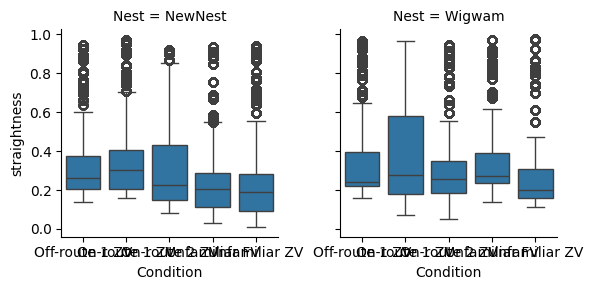

In [24]:
g = sns.FacetGrid(outdfTrimmed, col="Nest")
g.map_dataframe(sns.boxplot, x = "Condition",y="straightness")

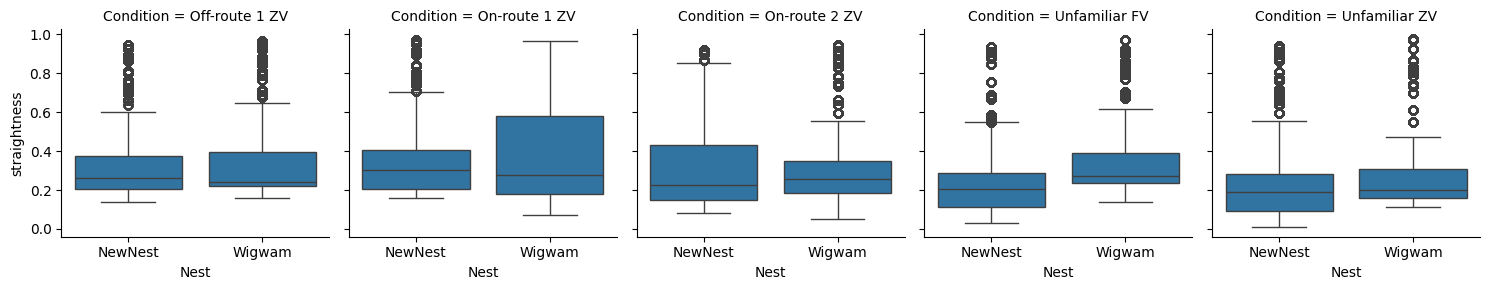

In [25]:
g = sns.FacetGrid(outdfTrimmed, col="Condition")
g.map_dataframe(sns.boxplot, x = "Nest",y="straightness")

In [41]:
import pandas as pd
import scipy.stats as stats
from scipy.stats import tukey_hsd
import numpy as np
from itertools import combinations

# Assuming your dataframe is called 'df'
dependent_variables = ['ave_speed', 'straightness', 'total_dist']

def analyze_pairwise_differences(df, dependent_var):
    """
    Perform comprehensive pairwise analysis for multiple conditions
    """
    print(f"\n{'='*60}")
    print(f"ANALYSIS FOR: {dependent_var.upper()}")
    print(f"{'='*60}")
    df1 = df[df['Nest']== 'Wigwam']
    df2 =  df[df['Nest']== 'NewNest']
    
    # 1. Basic descriptive statistics by condition
    print("\n1. DESCRIPTIVE STATISTICS BY CONDITION:")
    print("-" * 50)
    
    desc_stats1 = df1.groupby('Condition')[dependent_var].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(4)
    desc_stats2 = df2.groupby('Condition')[dependent_var].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(4)
    
    # Sort by mean to see which conditions have highest/lowest values
    desc_stats_sorted1 = desc_stats1.sort_values('mean', ascending=False)
    #print(np.unique(desc_stats1['Nest']),desc_stats_sorted1)
    desc_stats_sorted2 = desc_stats2.sort_values('mean', ascending=False)
    #print(np.unique(desc_stats2['Nest']),desc_stats_sorted2)
    
    # 2. Tukey HSD Post-hoc Test
    print(f"\n2. TUKEY HSD PAIRWISE COMPARISONS:")
    print("-" * 50)
    
    condition_names = sorted(df1['Condition'].unique())

    condition_data1 = []
    condition_data2 = []
    
    for cond in condition_names:
        data1 = df1[df1['Condition'] == cond][dependent_var].dropna().values
        condition_data1.append(data1)

        data2 = df2[df2['Condition'] == cond][dependent_var].dropna().values
        condition_data2.append(data2)
    
    try:
        # Perform Tukey HSD
        tukey_result1 = tukey_hsd(*condition_data1)
        tukey_result2 = tukey_hsd(*condition_data2)
        
        # Create a results dataframe for easier viewing
        significant_pairs1 = []
        significant_pairs2 = []
        
        for i in range(len(condition_names)):
            for j in range(i+1, len(condition_names)):
                cond1 = condition_names[i]
                cond2 = condition_names[j]
                p_val = tukey_result1.pvalue[i, j]
                
                mean1 = df1[df1['Condition'] == cond1][dependent_var].mean()
                mean2 = df1[df1['Condition'] == cond2][dependent_var].mean()
                mean_diff = mean1 - mean2
                
                significant_pairs1.append({
                    'Condition_1': cond1,
                    'Condition_2': cond2,
                    'Mean_1': round(mean1, 4),
                    'Mean_2': round(mean2, 4),
                    'Mean_Difference': round(mean_diff, 4),
                    'p_value': p_val,
                    'Significant': 'Yes' if p_val < 0.05 else 'No'
                })

        for i in range(len(condition_names)):
            for j in range(i+1, len(condition_names)):
                cond1 = condition_names[i]
                cond2 = condition_names[j]
                p_val = tukey_result2.pvalue[i, j]
                
                mean1 = df2[df2['Condition'] == cond1][dependent_var].mean()
                mean2 = df2[df2['Condition'] == cond2][dependent_var].mean()
                mean_diff = mean1 - mean2
                
                significant_pairs2.append({
                    'Condition_1': cond1,
                    'Condition_2': cond2,
                    'Mean_1': round(mean1, 4),
                    'Mean_2': round(mean2, 4),
                    'Mean_Difference': round(mean_diff, 4),
                    'p_value': p_val,
                    'Significant': 'Yes' if p_val < 0.05 else 'No'
                })
        
        # Convert to DataFrame and sort by p-value
        pairs_df1 = pd.DataFrame(significant_pairs1)
        pairs_df1 = pairs_df.sort_values('p_value')

        pairs_df2 = pd.DataFrame(significant_pairs2)
        pairs_df2 = pairs_df.sort_values('p_value')
        
        # Show only significant pairs
        significant_only1 = pairs_df1[pairs_df1['Significant'] == 'Yes']
        significant_only2 = pairs_df2[pairs_df2['Significant'] == 'Yes']
        
        print(f"Wigwam: SIGNIFICANT PAIRS (p < 0.05): {len(significant_only1)} out of {len(pairs_df1)} total comparisons")
        print()
        print(f"NewNest SIGNIFICANT PAIRS (p < 0.05): {len(significant_only2)} out of {len(pairs_df2)} total comparisons")
        print()
        
        if len(significant_only1) > 0:
            # Show top 20 most significant pairs
            print("Wigwam Top 20 most significant pairwise differences:")
            print(significant_only1.head(20).to_string(index=False))
        else:
            print("Wigwam No significant pairwise differences found!")
            
        if len(significant_only2) > 0:
            # Show top 20 most significant pairs
            print("NewNest  Top 20 most significant pairwise differences:")
            print(significant_only2.head(20).to_string(index=False))
        else:
            print("NewNest No significant pairwise differences found!")
            
        # 3. Summary of which conditions are "different"
        print(f"\n3. CONDITION RANKING (by mean {dependent_var}):")
        print("-" * 50)
        
        condition_means1 = df1.groupby('Conditions')[dependent_var].mean().sort_values(ascending=False)
        for i, (condition, mean_val) in enumerate(condition_means1.items(), 1):
            print(f"Wigwam {i:2d}. {condition}: {mean_val:.4f}")
            
        condition_means2 = df2.groupby('Conditions')[dependent_var].mean().sort_values(ascending=False)
        for i, (condition, mean_val) in enumerate(condition_means2.items(), 1):
            print(f"NewNEst {i:2d}. {condition}: {mean_val:.4f}")
            
    except Exception as e:
        print(f"Error performing Tukey HSD: {e}")
        print("Trying alternative pairwise t-tests with Bonferroni correction...")
        
        # Alternative: Pairwise t-tests with Bonferroni correction
        pairwise_results1 = []
        pairwise_results2 = []
        condition_names = df['Condition'].unique()
        
        for cond1, cond2 in combinations(condition_names, 2):
            data1 = df1[df1['Condition'] == cond1][dependent_var].dropna()
            data2 = df1[df1['Condition'] == cond2][dependent_var].dropna()
            
            if len(data1) > 0 and len(data2) > 0:
                t_stat, p_val = stats.ttest_ind(data1, data2)
                
                # Bonferroni correction
                n_comparisons1 = len(list(combinations(condition_names, 2)))
                p_corrected1 = min(p_val * n_comparisons1, 1.0)
                
                pairwise_results1.append({
                    'Condition_1': cond1,
                    'Condition_2': cond2,
                    'Mean_1': data1.mean(),
                    'Mean_2': data2.mean(),
                    'p_value_corrected': p_corrected1,
                    'Significant': 'Yes' if p_corrected1 < 0.05 else 'No'
                })
            for cond1, cond2 in combinations(condition_names, 2):
                data1 = df2[df2['Condition'] == cond1][dependent_var].dropna()
                data2 = df2[df2['Condition'] == cond2][dependent_var].dropna()
                
                if len(data1) > 0 and len(data2) > 0:
                    t_stat, p_val = stats.ttest_ind(data1, data2)
                    
                    # Bonferroni correction
                    n_comparisons2 = len(list(combinations(condition_names, 2)))
                    p_corrected2 = min(p_val * n_comparisons2, 1.0)
                    
                    pairwise_results2.append({
                        'Condition_1': cond1,
                        'Condition_2': cond2,
                        'Mean_1': data1.mean(),
                        'Mean_2': data2.mean(),
                        'p_value_corrected': p_corrected2,
                        'Significant': 'Yes' if p_corrected2 < 0.05 else 'No'
                    })
        
        pairs_df1 = pd.DataFrame(pairwise_results1)
        significant_only1 = pairs_df1[pairs_df1['Significant'] == 'Yes']
        pairs_df2 = pd.DataFrame(pairwise_results2)
        significant_only2 = pairs_df2[pairs_df2['Significant'] == 'Yes']
        
        print(f"Wigwam SIGNIFICANT PAIRS (Bonferroni corrected): {len(significant_only1)}")
        if len(significant_only1) > 0:
            print(significant_only1.to_string(index=False))

        print(f"NewNest SIGNIFICANT PAIRS (Bonferroni corrected): {len(significant_only2)}")
        if len(significant_only2) > 0:
            print(significant_only2.to_string(index=False))

# Run analysis for each dependent variable
for var in dependent_variables:
    analyze_pairwise_differences(outdfTrimmed, var)

# BONUS: Create a summary matrix showing which conditions are significantly different
print(f"\n{'='*60}")
print("SUMMARY: SIGNIFICANCE MATRIX")
print(f"{'='*60}")

wwdf = outdfTrimmed[outdfTrimmed['Nest']=='Wigwam']
nndf = outdfTrimmed[outdfTrimmed['Nest']=='Newnest']

for var in dependent_variables:
    print(f"\n{var.upper()} - Significant Differences Matrix:")
    print("(1 = significantly different, 0 = not significantly different)")
    
    condition_names = sorted(wwdf['Condition'].unique())
    
    # Create significance matrix
    sig_matrix1 = np.zeros((len(condition_names), len(condition_names)))
    
    for i, cond1 in enumerate(condition_names):
        for j, cond2 in enumerate(condition_names):
            if i != j:
                data1 = wwdf[wwdf['Condition'] == cond1][var].dropna()
                data2 = wwdf[wwdf['Condition'] == cond2][var].dropna()
                
                if len(data1) > 0 and len(data2) > 0:
                    _, p_val = stats.ttest_ind(data1, data2)
                    # Apply Bonferroni correction
                    p_corrected = min(p_val * len(condition_names) * (len(condition_names) - 1) / 2, 1.0)
                    sig_matrix1[i, j] = 1 if p_corrected < 0.05 else 0

    for var in dependent_variables:
        print(f"\n{var.upper()} - Significant Differences Matrix:")
        print("(1 = significantly different, 0 = not significantly different)")
        
        condition_names = sorted(nndf['Condition'].unique())
        
        # Create significance matrix
        sig_matrix2 = np.zeros((len(condition_names), len(condition_names)))
        
        for i, cond1 in enumerate(condition_names):
            for j, cond2 in enumerate(condition_names):
                if i != j:
                    data1 = nndf[nndf['Condition'] == cond1][var].dropna()
                    data2 = nndf[nndf['Condition'] == cond2][var].dropna()
                    
                    if len(data1) > 0 and len(data2) > 0:
                        _, p_val = stats.ttest_ind(data1, data2)
                        # Apply Bonferroni correction
                        p_corrected = min(p_val * len(condition_names) * (len(condition_names) - 1) / 2, 1.0)
                        sig_matrix2[i, j] = 1 if p_corrected < 0.05 else 0
        
    # Convert to DataFrame for better display
    sig_df1 = pd.DataFrame(sig_matrix1, index=condition_names, columns=condition_names)
    print(sig_df1)
    sig_df2 = pd.DataFrame(sig_matrix2, index=condition_names, columns=condition_names)
    print(sig_df2)


ANALYSIS FOR: AVE_SPEED

1. DESCRIPTIVE STATISTICS BY CONDITION:
--------------------------------------------------

2. TUKEY HSD PAIRWISE COMPARISONS:
--------------------------------------------------
Error performing Tukey HSD: name 'pairs_df' is not defined
Trying alternative pairwise t-tests with Bonferroni correction...
Wigwam SIGNIFICANT PAIRS (Bonferroni corrected): 10
   Condition_1   Condition_2    Mean_1    Mean_2  p_value_corrected Significant
Off-route 1 ZV On-route 1 ZV 37.756626 41.847588      5.739785e-176         Yes
Off-route 1 ZV On-route 2 ZV 37.756626 40.888504      2.583226e-161         Yes
Off-route 1 ZV Unfamiliar FV 37.756626 30.479619       0.000000e+00         Yes
Off-route 1 ZV Unfamiliar ZV 37.756626 32.367186       0.000000e+00         Yes
 On-route 1 ZV On-route 2 ZV 41.847588 40.888504       8.769127e-11         Yes
 On-route 1 ZV Unfamiliar FV 41.847588 30.479619       0.000000e+00         Yes
 On-route 1 ZV Unfamiliar ZV 41.847588 32.367186       0.00

ValueError: Shape of passed values is (5, 5), indices imply (0, 0)

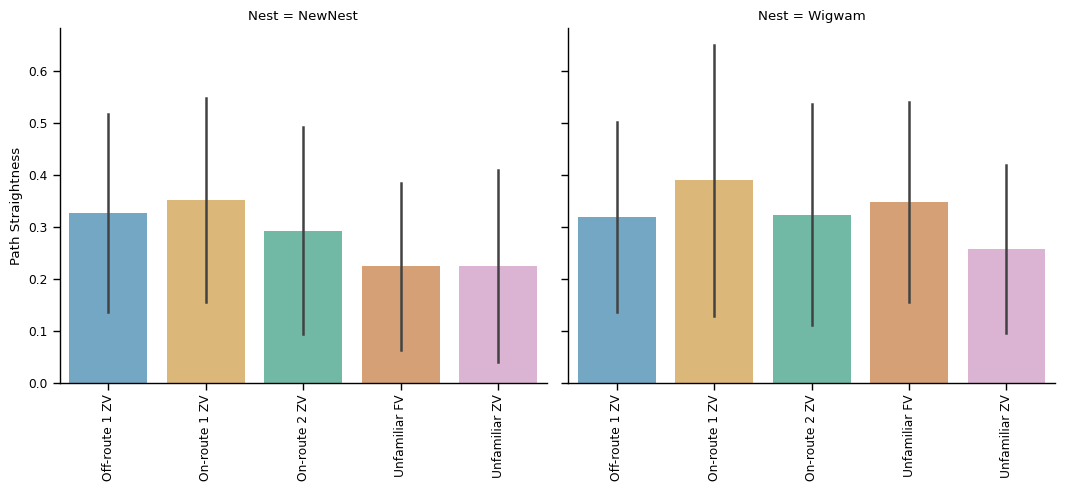

In [26]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= outdfTrimmed, kind= "bar",
        x="Condition", y="straightness", col='Nest', hue = 'Condition', #row='lr',
        errorbar="sd", palette="colorblind", alpha=.6)#, height=12, margin_titles=True .set_titles(f"{row_name} \n{col_name}")

    def add_stripplot(x, y, **kwargs):
        ax = plt.gca()
        data = kwargs.pop("data")
        sns.stripplot(x=x, y=y, data=data, ax=ax, dodge=True, alpha=0.8, linewidth=1)
    
    # Apply the stripplot function to each subplot
    #g.map_dataframe(add_stripplot, "test_type", "Model_performance")
    for ax in g.axes_dict.values():
        g.tick_params(axis='x', rotation=90) #, size=25
        #ax.axline((0, 9), slope=0, c="0.4", ls="--", zorder=0)
        ax.tick_params(axis='both', which='major') #, labelsize=26

        g.set_axis_labels("", "Path Straightness") 

    plt.tight_layout()

    g._legend.remove()

    #plt.savefig(""+'.jpeg', format='jpeg',bbox_inches="tight")

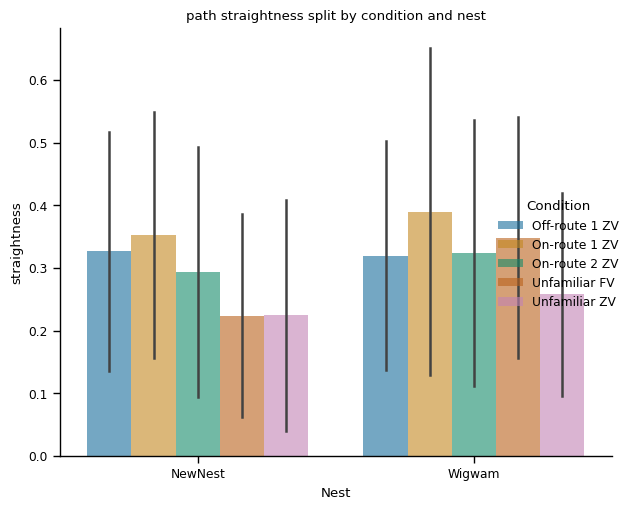

In [27]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= outdfTrimmed, kind= "bar",
        x="Nest", y="straightness", hue = 'Condition', #row='lr', col='Condition', 
        errorbar="sd", palette="colorblind", alpha=.6)#, height=12, margin_titles=True .set_titles(f"{row_name} \n{col_name}")

    def add_stripplot(x, y, **kwargs):
        ax = plt.gca()
        data = kwargs.pop("data")
        sns.stripplot(x=x, y=y, data=data, ax=ax, dodge=True, alpha=0.8, linewidth=1)
    
    # Apply the stripplot function to each subplot
    #g.map_dataframe(add_stripplot, "test_type", "Model_performance")
    for ax in g.axes_dict.values():
        g.tick_params(axis='x', rotation=90) #, size=25
        #ax.axline((0, 9), slope=0, c="0.4", ls="--", zorder=0)
        ax.tick_params(axis='both', which='major') #, labelsize=26

        g.set_axis_labels("", "Path Straightness") 

    plt.tight_layout()

    #g._legend.remove()
    plt.title("path straightness split by condition and nest")

    #plt.savefig(""+'.jpeg', format='jpeg',bbox_inches="tight")

In [44]:
outdfTrimmed.keys()

Index(['Date', 'ID', 'frame', 'x', 'y', 'Nest', 'Condition',
       'delta_distance(pix)', 'speed(px/s)', 'accumdist', 'ave_speed',
       'total_dist', 'straightness'],
      dtype='object')

In [51]:
# Identify the stats columns (numeric measurement columns)
stats_columns = ['ave_speed',  'straightness']

# Identify the ID columns (columns that identify each observation)
id_columns = ['Date', 'ID', 'frame', 'x', 'y', 'Nest', 'Condition']

# Method 1: Using melt() - most common approach
outdfTrimmed_long = outdfTrimmed.melt(
    id_vars=id_columns,
    value_vars=stats_columns,
    var_name='stats_type',
    value_name='stats_val'
)

In [52]:
outdfTrimmed_long.head()

,Date,ID,frame,x,y,Nest,Condition,stats_type,stats_val
0,Aug-21,561,0.0,9.136518,-2.818835,NewNest,Off-route 1 ZV,ave_speed,26.702984
1,Aug-21,561,1.0,9.182885,-2.805765,NewNest,Off-route 1 ZV,ave_speed,26.702984
2,Aug-21,561,2.0,9.191697,-2.636927,NewNest,Off-route 1 ZV,ave_speed,26.702984
3,Aug-21,561,3.0,9.230887,-2.650137,NewNest,Off-route 1 ZV,ave_speed,26.702984
4,Aug-21,561,4.0,9.196637,-2.753849,NewNest,Off-route 1 ZV,ave_speed,26.702984


In [62]:
print(np.unique(outdfTrimmed_long['Condition']))

conds = np.unique(outdfTrimmed_long['Condition'])

array(['Off-route 1 ZV', 'On-route 1 ZV', 'On-route 2 ZV',
       'Unfamiliar FV', 'Unfamiliar ZV'], dtype=object)

In [75]:
unique_nests = sorted(outdfTrimmed_long['Nest'].unique())
print(unique_nests)
if len(unique_nests) == 2:
    nest_mapping_auto = {
        unique_nests[0]: 'nest2',
        unique_nests[1]: 'nest1'
    }
    outdfTrimmed_long['Nest'] = outdfTrimmed_long['Nest'].replace(nest_mapping_auto)

['NewNest', 'Wigwam']


In [76]:
unique_nests = sorted(outdfTrimmed_long['Nest'].unique())
print(unique_nests)

['nest1', 'nest2']


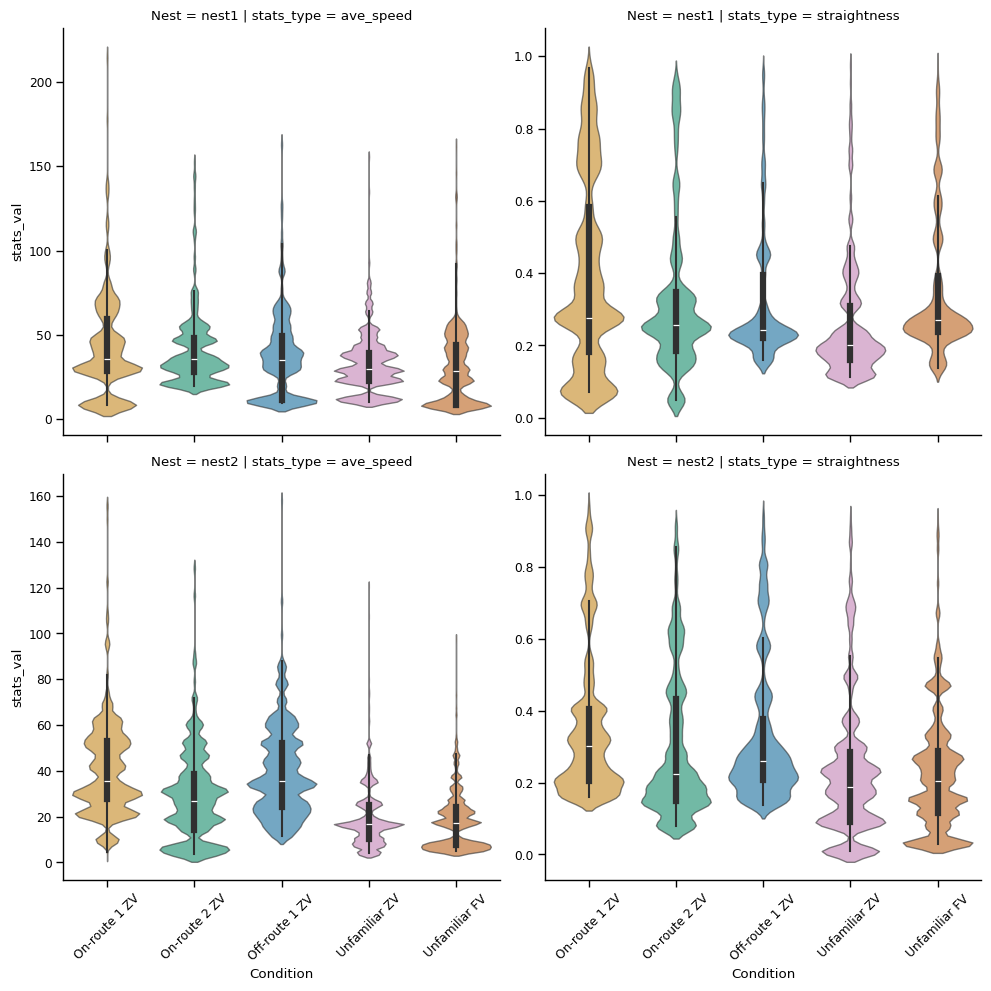

In [79]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= outdfTrimmed_long, kind= "violin",row='Nest', row_order=['nest1','nest2'],col='stats_type', hue='Condition',
        x="Condition", y='stats_val', order=['On-route 1 ZV', 'On-route 2 ZV', 'Off-route 1 ZV', 'Unfamiliar ZV', 'Unfamiliar FV'], #row='lr', col='Condition', 
        errorbar="sd", palette="colorblind", alpha=.6, sharey=False, margin_titles=False, legend=False)#, height=12, margin_titles=True .set_titles(f"{row_name} \n{col_name}")


    
    # Apply the stripplot function to each subplot
    #g.map_dataframe(add_stripplot, "test_type", "Model_performance")
    for ax in g.axes_dict.values():
        g.tick_params(axis='x', rotation=45) #, size=25
        #ax.axline((0, 9), slope=0, c="0.4", ls="--", zorder=0)
        ax.tick_params(axis='both', which='major') #, labelsize=26

        #g.set_axis_labels("", "Path Straightness") 

    plt.tight_layout()

    #g._legend.remove()
    #plt.title("Path straightness split by condition")

    plt.savefig(save_folder+"Facet_WWNN_speedStraightness"+'.jpeg', format='jpeg',bbox_inches="tight")

/tmp/ipykernel_74887/3680358984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


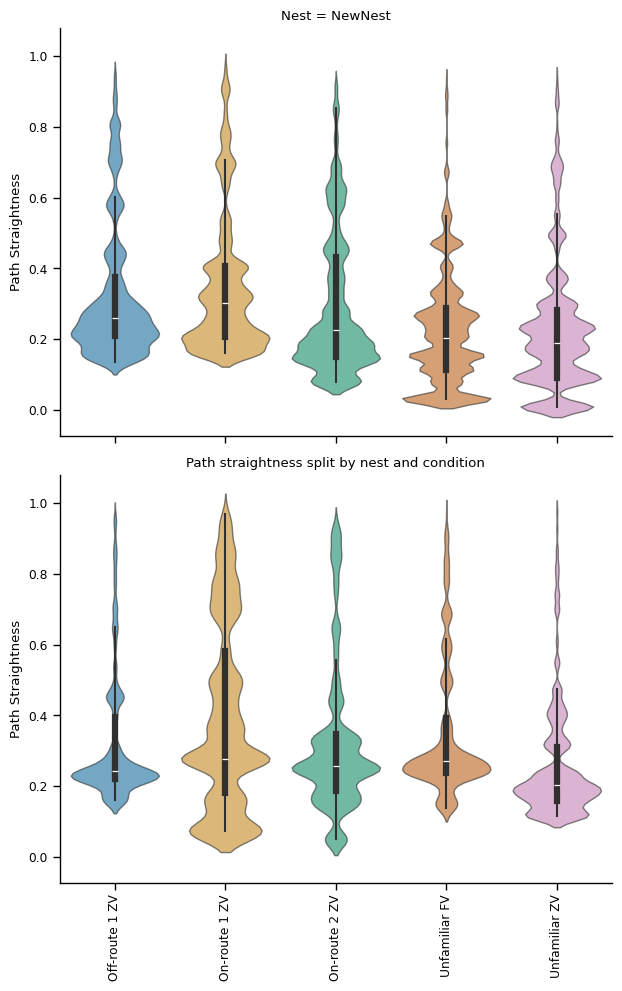

In [64]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= outdfTrimmed, kind= "violin", row='Nest',
        x="Condition", y="straightness", #row='lr', col='Condition', 
        errorbar="sd", palette="colorblind", alpha=.6)#, height=12, margin_titles=True .set_titles(f"{row_name} \n{col_name}")

    def add_stripplot(x, y, **kwargs):
        ax = plt.gca()
        data = kwargs.pop("data")
        sns.stripplot(x=x, y=y, data=data, ax=ax, dodge=True, alpha=0.8, linewidth=1)
    
    # Apply the stripplot function to each subplot
    #g.map_dataframe(add_stripplot, "test_type", "Model_performance")
    for ax in g.axes_dict.values():
        g.tick_params(axis='x', rotation=90) #, size=25
        #ax.axline((0, 9), slope=0, c="0.4", ls="--", zorder=0)
        ax.tick_params(axis='both', which='major') #, labelsize=26

        g.set_axis_labels("", "Path Straightness") 

    plt.tight_layout()

    g._legend.remove()
    plt.title("Path straightness split by nest and condition")

    #plt.savefig(""+'.jpeg', format='jpeg',bbox_inches="tight")

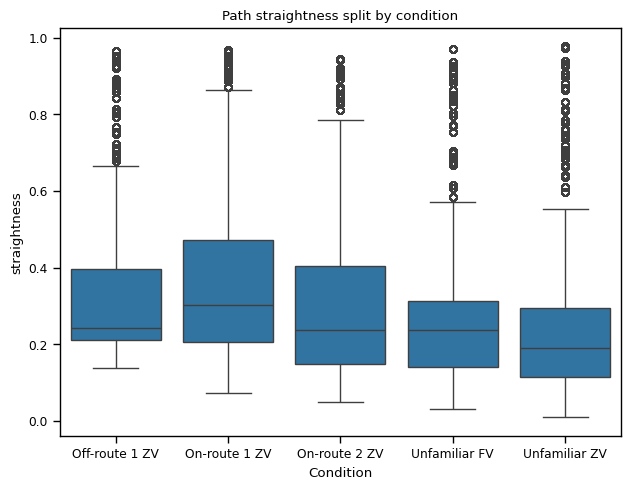

In [30]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):

    sns.boxplot(outdfTrimmed, x="Condition", y="straightness")
    plt.tight_layout()

    #g._legend.remove()
    plt.title("Path straightness split by condition")

    #plt.savefig(""+'.jpeg', format='jpeg',bbox_inches="tight")

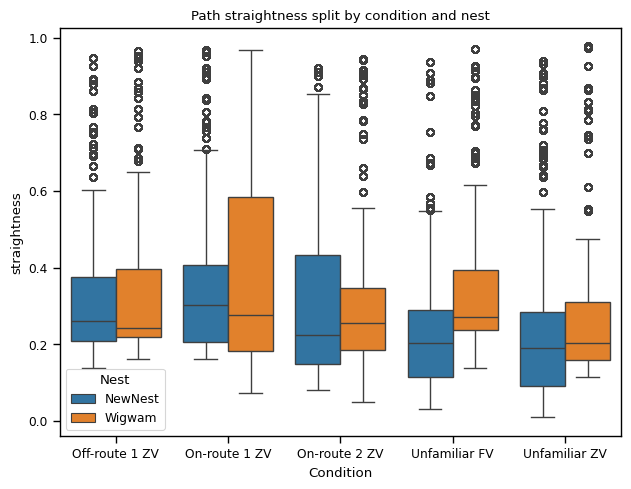

In [31]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):

    sns.boxplot(outdfTrimmed, x="Condition", y="straightness", hue='Nest')
    plt.tight_layout()

    #g._legend.remove()
    plt.title("Path straightness split by condition and nest")

    #plt.savefig(""+'.jpeg', format='jpeg',bbox_inches="tight")

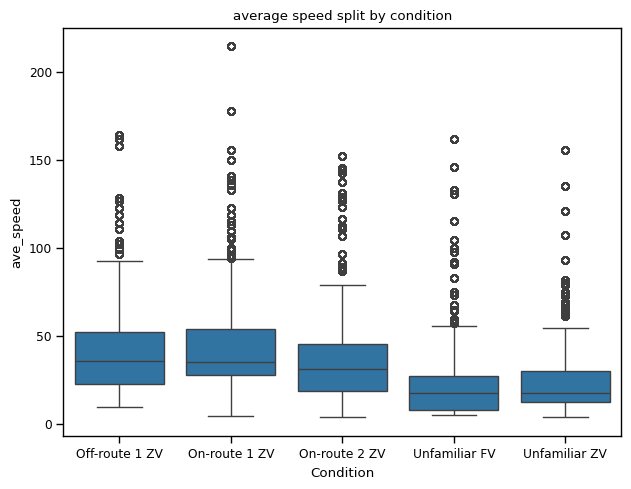

In [32]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):

    sns.boxplot(outdfTrimmed, x="Condition", y="ave_speed")
    plt.tight_layout()

    #g._legend.remove()
    plt.title("average speed split by condition")

    #plt.savefig(""+'.jpeg', format='jpeg',bbox_inches="tight")

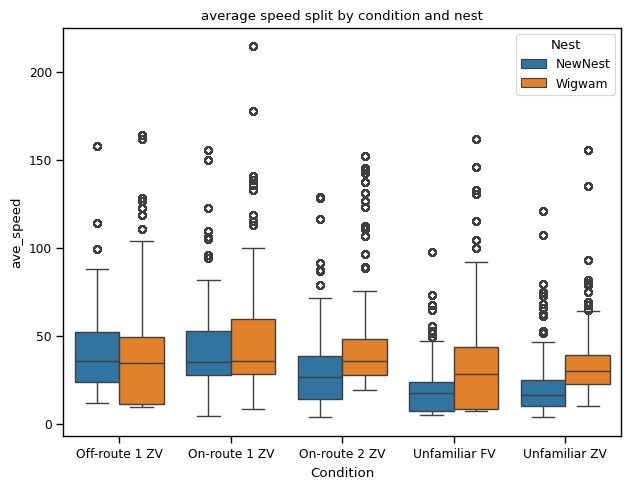

In [33]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):

    sns.boxplot(outdfTrimmed, x="Condition", y="ave_speed", hue='Nest')
    plt.tight_layout()

    #g._legend.remove()
    plt.title("average speed split by condition and nest")

    #plt.savefig(""+'.jpeg', format='jpeg',bbox_inches="tight")

In [ ]:
sns.pairplot(outdfTrimmed, hue="Condition")

In [ ]:
outdfTrimmed.keys()

In [ ]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= outdfTrimmed, kind= "violin",
        x="Condition", y="straightness", #row='lr', col='Condition', 
        errorbar="sd", palette="colorblind", alpha=.6)#, height=12, margin_titles=True .set_titles(f"{row_name} \n{col_name}")


    # Apply the stripplot function to each subplot
    #g.map_dataframe(add_stripplot, "test_type", "Model_performance")
    for ax in g.axes_dict.values():
        g.tick_params(axis='x', rotation=90) #, size=25
        #ax.axline((0, 9), slope=0, c="0.4", ls="--", zorder=0)
        ax.tick_params(axis='both', which='major') #, labelsize=26

        g.set_axis_labels("", "Path Straightness") 

    plt.tight_layout()

    g._legend.remove()
    #plt.title("Average speed split by condition")
    title = "Path straightness split by condition"
    plt.title(title)
    plt.savefig("abbotsplots/multipath/"+title+'.jpeg', format='jpeg',bbox_inches="tight")

    #plt.savefig(""+'.jpeg', format='jpeg',bbox_inches="tight")

In [ ]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= outdfTrimmed, kind= "violin",
        x="Condition", y="ave_speed", #row='lr', col='Condition', 
        errorbar="sd", palette="colorblind", alpha=.6)#, height=12, margin_titles=True .set_titles(f"{row_name} \n{col_name}")


    # Apply the stripplot function to each subplot
    #g.map_dataframe(add_stripplot, "test_type", "Model_performance")
    for ax in g.axes_dict.values():
        g.tick_params(axis='x', rotation=90) #, size=25
        #ax.axline((0, 9), slope=0, c="0.4", ls="--", zorder=0)
        ax.tick_params(axis='both', which='major') #, labelsize=26

        g.set_axis_labels("", "Path Straightness") 

    plt.tight_layout()

    g._legend.remove()
    #plt.title("Average speed split by condition")
    title = "Average speed travelled split by condition"
    plt.title(title)
    plt.savefig("abbotsplots/multipath/"+title+'.jpeg', format='jpeg',bbox_inches="tight")

    #plt.savefig(""+'.jpeg', format='jpeg',bbox_inches="tight")

In [ ]:

with sns.plotting_context("paper", font_scale=1):#, rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= outdfTrimmed, kind= "violin",
        x="Condition", y="total_dist", #row='lr', col='Condition', 
        errorbar="sd", palette="colorblind", alpha=.6)#, height=12, margin_titles=True .set_titles(f"{row_name} \n{col_name}")

    def add_stripplot(x, y, **kwargs):
        ax = plt.gca()
        data = kwargs.pop("data")
        sns.stripplot(x=x, y=y, data=data, ax=ax, dodge=True, alpha=0.8, linewidth=1)
    
    # Apply the stripplot function to each subplot
    #g.map_dataframe(add_stripplot, "test_type", "Model_performance")
    for ax in g.axes_dict.values():
        g.tick_params(axis='x', rotation=90) #, size=25
        #ax.axline((0, 9), slope=0, c="0.4", ls="--", zorder=0)
        ax.tick_params(axis='both', which='major') #, labelsize=26

        #g.set_axis_labels("", "Path Straightness") 

    plt.tight_layout()

    g._legend.remove()
    title = "Total distance travelled split by condition"
    plt.title(title)
    plt.savefig("abbotsplots/multipath/"+title+'.jpeg', format='jpeg',bbox_inches="tight")